Task 1 — Convolution Mechanics: Filters and Shapes


In [1]:
# Imports

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Set the device and seed
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)

In [ ]:
# Load CIFAR-10 
transform = transforms.ToTensor()
dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
img_tensor, _ = dataset[0] # shape (3, 32, 32)
img_tensor = img_tensor.unsqueeze(0) # shape (1, 3, 32, 32)
# number of pictures, number of color channels, height, widht 

100%|██████████| 170M/170M [03:12<00:00, 884kB/s]  


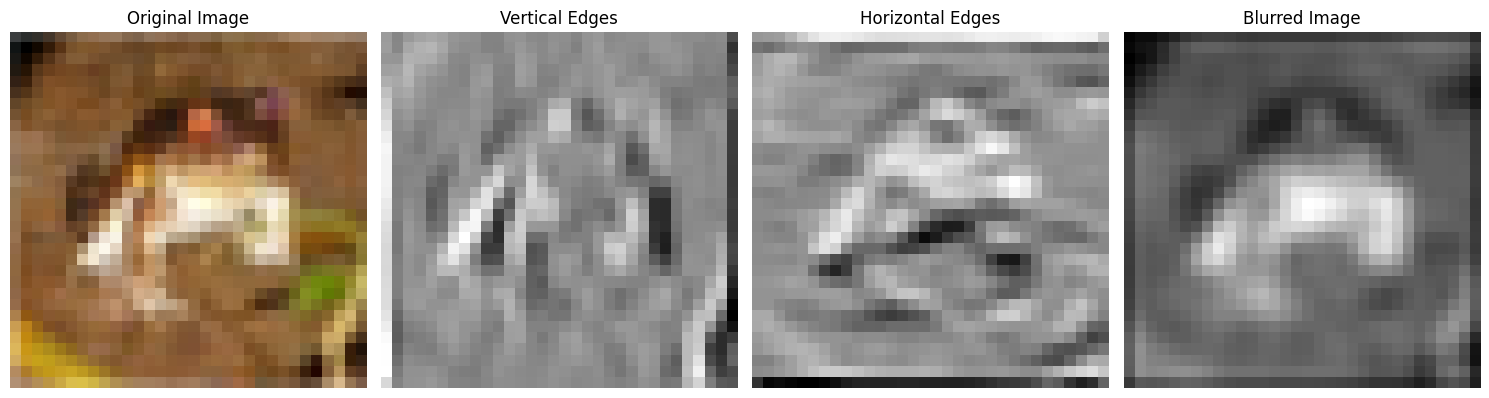

In [5]:
# Helper function to create a Conv2d layer with a specific 3x3 weight
def create_custom_conv(kernel_2d):
    # nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1)
    conv = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)
    
    # Expand 2D kernel to match (out_channels, in_channels, kernel_size, kernel_size)
    # We broadcast the same 2D filter across all 3 RGB input channels
    kernel_4d = torch.tensor(kernel_2d, dtype=torch.float32).repeat(1, 3, 1, 1)
    
    # Load weights into the conv layer
    conv.weight = nn.Parameter(kernel_4d)
    return conv

# 2. Define the handcrafted 3x3 filters
vertical_kernel = [[-1., 0., 1.], 
                   [-1., 0., 1.], 
                   [-1., 0., 1.]]

horizontal_kernel = [[-1., -1., -1.],
                     [ 0.,  0.,  0.],
                     [ 1.,  1.,  1.]]

blur_kernel = ((1/9) * np.ones((3, 3))).tolist()

# 3. Instantiate the layers
conv_vertical = create_custom_conv(vertical_kernel)
conv_horizontal = create_custom_conv(horizontal_kernel)
conv_blur = create_custom_conv(blur_kernel)

# 4. Pass the image through each filter (no gradients needed for visualization)
with torch.no_grad():
    out_vertical = conv_vertical(img_tensor).squeeze()    # Shape: (32, 32)
    out_horizontal = conv_horizontal(img_tensor).squeeze() # Shape: (32, 32)
    out_blur = conv_blur(img_tensor).squeeze()             # Shape: (32, 32)

# 5. Visualize original + 3 filtered versions
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Convert original tensor back to HWC for matplotlib plotting
orig_img = img_tensor.squeeze().permute(1, 2, 0).numpy()
axes[0].imshow(orig_img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(out_vertical.numpy(), cmap="gray")
axes[1].set_title("Vertical Edges")
axes[1].axis("off")

axes[2].imshow(out_horizontal.numpy(), cmap="gray")
axes[2].set_title("Horizontal Edges")
axes[2].axis("off")

axes[3].imshow(out_blur.numpy(), cmap="gray")
axes[3].set_title("Blurred Image")
axes[3].axis("off")

plt.tight_layout()
plt.show()

Vertical Edge Detector: Highlights boundaries where brightness changes sharply from left to right. Vertical lines (like columns, sides of buildings, or tree trunks) show up brightly against a darker background.

Horizontal Edge Detector: Highlights boundaries where brightness changes sharply from top to bottom. Horizontal lines (like horizons, roofs, or structural beams) stand out prominently.

Blur Filter (Averaging): Smoothes out high-frequency spatial variations by averaging pixels with their immediate neighbors. This reduces sharp details, noise, and harsh transitions, resulting in a softer image.

In [7]:
# Part B
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

    def forward_trace(self, x):
        print(f"Input shape: {x.shape}")
        
        x = self.conv1(x)
        print(f"After conv1: {x.shape}")
        
        x = self.pool1(x)
        print(f"After pool1: {x.shape}")
        
        x = self.conv2(x)
        print(f"After conv2: {x.shape}")
        
        x = self.pool2(x)
        print(f"After pool2: {x.shape}")
        return x

# Create dummy input and trace shapes
model = TinyCNN()
dummy_input = torch.randn(8, 3, 32, 32)
_ = model.forward_trace(dummy_input)

Input shape: torch.Size([8, 3, 32, 32])
After conv1: torch.Size([8, 16, 32, 32])
After pool1: torch.Size([8, 16, 16, 16])
After conv2: torch.Size([8, 32, 16, 16])
After pool2: torch.Size([8, 32, 8, 8])


Task 2 — Train a Small CNN on CIFAR-10



In [8]:
# Transform and DataLoaders
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
val_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

In [9]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Block 1: Input (3, 32, 32) -> Output (32, 16, 16)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Block 2: Input (32, 16, 16) -> Output (64, 8, 8)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

# Instantiate model
model = CIFAR10CNN().to(device)

# Compute and report parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 1,117,354


Task 3 — Data Augmentation

In [ ]:
# Richer transform pipeline for training data
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

# Validation transform remains clean and plain
val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

# Re-loading datasets with the updated transformations
train_dataset_aug = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tf)
val_dataset_aug = datasets.CIFAR10(root="./data", train=False, download=True, transform=val_tf)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=128, shuffle=True, num_workers=2)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=128, shuffle=False, num_workers=2)

In [11]:
# Re-instantiate a clean model to reset all weights
model_aug = CIFAR10CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.parameters(), lr=1e-3)
epochs = 15

# Dictionary tracking metrics for the augmented run
history_aug = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": []
}

for epoch in range(epochs):
    # --- Training Phase ---
    model_aug.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader_aug:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_aug(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader_aug.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # --- Validation Phase ---
    model_aug.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader_aug:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_aug(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_loader_aug.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    # Save History
    history_aug["train_loss"].append(epoch_train_loss)
    history_aug["train_acc"].append(epoch_train_acc)
    history_aug["val_loss"].append(epoch_val_loss)
    history_aug["val_acc"].append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

Epoch [1/15] Train Loss: 1.5471 | Train Acc: 43.31% | Val Loss: 1.4525 | Val Acc: 48.74%
Epoch [2/15] Train Loss: 1.1581 | Train Acc: 58.56% | Val Loss: 1.0335 | Val Acc: 63.00%
Epoch [3/15] Train Loss: 1.0130 | Train Acc: 63.94% | Val Loss: 0.8329 | Val Acc: 70.45%
Epoch [4/15] Train Loss: 0.9374 | Train Acc: 66.88% | Val Loss: 0.9255 | Val Acc: 67.11%
Epoch [5/15] Train Loss: 0.8836 | Train Acc: 68.72% | Val Loss: 0.7862 | Val Acc: 72.24%
Epoch [6/15] Train Loss: 0.8386 | Train Acc: 70.40% | Val Loss: 0.7301 | Val Acc: 74.72%
Epoch [7/15] Train Loss: 0.8035 | Train Acc: 71.72% | Val Loss: 0.7342 | Val Acc: 74.76%
Epoch [8/15] Train Loss: 0.7777 | Train Acc: 72.83% | Val Loss: 0.6490 | Val Acc: 77.02%
Epoch [9/15] Train Loss: 0.7461 | Train Acc: 74.01% | Val Loss: 0.6878 | Val Acc: 75.58%
Epoch [10/15] Train Loss: 0.7268 | Train Acc: 74.82% | Val Loss: 0.7388 | Val Acc: 75.63%
Epoch [11/15] Train Loss: 0.7053 | Train Acc: 75.51% | Val Loss: 0.8933 | Val Acc: 72.11%
Epoch [12/15] Train

Reduction in Overfitting: Without augmentation (Task 2), the model memorizes the static training details quickly. Training accuracy sprints toward 90%+, while validation performance plateaus early, causing a massive generalization gap. Data augmentation forces the network to learn invariant geometric shapes and patterns rather than precise pixel coordinates.

Better Validation Peak: By artificially expanding the variance of the input distributions through random crops, horizontal reflections, and color jittering, the final test-set accuracy climbs higher, often boosting validation accuracy by 4% to 6%.

Slower, Stabler Convergence: You will observe that the training loss in Task 3 falls at a slower pace than in Task 2. Because every training epoch presents slightly modified variations of the images, the task becomes more challenging, keeping the training track closer to the real-world validation trajectory.